In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly
!pip install prophet xgboost lightgbm shap
!pip install torch torchvision
!pip install tensorflow keras
!pip install scipy statsmodels
!pip install yellowbrick imbalanced-learn
!pip install wordcloud nltk textblob
!pip install optuna  # hyperparameter optimization
print(" All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.4 MB/s eta 0:00:00
 All libraries installed!


In [2]:
# CELL 2: All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              silhouette_score, davies_bouldin_score)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Time Series
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# NLP
import nltk
from wordcloud import WordCloud
from textblob import TextBlob
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(" All imports are loaded")

 All imports are loaded


In [3]:
# CELL 3: Generate advanced realistic dataset with noise, outliers, missings

np.random.seed(42)
N = 500  # large enough for deep learning

years = np.random.choice(range(1983, 2025), N)
baselines = pd.cut(years,
    bins=[1982,1990,1995,2000,2005,2010,2015,2020,2024],
    labels=['BL1','BL2','BL3','BL4','BL5','BL6','BL7','BL8'])

nations = np.random.choice(
    ['United States','Japan','South Korea','Spain','Norway','Australia'],
    N, p=[0.65, 0.13, 0.09, 0.06, 0.04, 0.03])

mission_types = np.random.choice(
    ['AAW','ASW','ASuW','BMD','Land Attack','Cyber','EW','C2'],
    N, p=[0.20,0.15,0.15,0.20,0.10,0.10,0.05,0.05])

year_norm = (years - 1983) / 41

radar_range     = 300 + 600*year_norm + np.random.normal(0, 35, N)
missile_range   = 120 + 380*year_norm + np.random.normal(0, 25, N)
targets         = (10 + 290*year_norm + np.random.normal(0, 20, N)).clip(5, 320).astype(int)
budget          = 0.5 + 3.7*year_norm + np.random.normal(0, 0.3, N)
integration     = (40 + 55*year_norm + np.random.normal(0, 4, N)).clip(35, 100)
cyber_score     = (5 + 90*year_norm**1.5 + np.random.normal(0, 5, N)).clip(3, 100)
network_score   = (8 + 90*year_norm**1.2 + np.random.normal(0, 4, N)).clip(5, 100)
crew_size       = (350 - 100*year_norm + np.random.normal(0, 20, N)).clip(150, 380).astype(int)
system_uptime   = (70 + 25*year_norm + np.random.normal(0, 3, N)).clip(65, 99.9)
response_time_ms= (5000 - 4500*year_norm + np.random.normal(0, 200, N)).clip(100, 5200)
bmd_capable     = (year_norm > 0.48).astype(int)
ships_deployed  = (1 + 121*year_norm**0.7 + np.random.normal(0, 5, N)).clip(1, 130).astype(int)

# Inject outliers (~3%)
outlier_idx = np.random.choice(N, int(0.03*N), replace=False)
radar_range[outlier_idx] *= np.random.uniform(1.4, 2.0, len(outlier_idx))
budget[outlier_idx] *= np.random.uniform(0.3, 0.5, len(outlier_idx))

# Mission capability score (target variable — complex nonlinear)
capability_score = (
    0.25 * (radar_range / radar_range.max()) +
    0.20 * (missile_range / missile_range.max()) +
    0.15 * cyber_score / 100 +
    0.15 * network_score / 100 +
    0.10 * integration / 100 +
    0.10 * (1 - response_time_ms / response_time_ms.max()) +
    0.05 * bmd_capable
) * 100 + np.random.normal(0, 2, N)
capability_score = capability_score.clip(10, 100)

df = pd.DataFrame({
    'Year': years,
    'Baseline': baselines,
    'Nation': nations,
    'Mission_Type': mission_types,
    'Radar_Range_km': radar_range.round(1),
    'Missile_Range_km': missile_range.round(1),
    'Simultaneous_Targets': targets,
    'Budget_BUSD': budget.round(3),
    'Integration_Score': integration.round(2),
    'Cyber_Score': cyber_score.round(2),
    'Network_Score': network_score.round(2),
    'Crew_Size': crew_size,
    'System_Uptime_pct': system_uptime.round(2),
    'Response_Time_ms': response_time_ms.round(1),
    'BMD_Capable': bmd_capable,
    'Ships_Deployed': ships_deployed,
    'Capability_Score': capability_score.round(3)
})

# Inject 5% missing values
for col in ['Radar_Range_km','Budget_BUSD','Cyber_Score','Response_Time_ms']:
    mask = np.random.random(N) < 0.05
    df.loc[mask, col] = np.nan

print(f" Dataset shape: {df.shape}")
print(f"   Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
print(df.describe().round(2))

 Dataset shape: (500, 17)
   Missing values:
Radar_Range_km      30
Budget_BUSD         28
Cyber_Score         32
Response_Time_ms    29
dtype: int64
          Year  Radar_Range_km  Missile_Range_km  Simultaneous_Targets  \
count   500.00          470.00            500.00                500.00   
mean   2004.33          626.36            318.32                160.71   
std      12.20          205.43            114.90                 88.23   
min    1983.00          225.20             80.40                  5.00   
25%    1994.00          466.88            223.12                 87.00   
50%    2006.00          638.50            334.45                171.50   
75%    2015.00          771.72            414.95                233.25   
max    2024.00         1542.30            555.80                320.00   

       Budget_BUSD  Integration_Score  Cyber_Score  Network_Score  Crew_Size  \
count       472.00             500.00       468.00         500.00     500.00   
mean          2.40     

In [4]:
# CELL 4: Full preprocessing pipeline

from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler

print("=== PREPROCESSING PIPELINE ===\n")

# 1. KNN Imputation (better than mean fill)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print(f" KNN imputation complete. Missing after: {df.isnull().sum().sum()}")

# 2. Outlier detection using IQR + Z-score hybrid
def flag_outliers(series, method='iqr', threshold=3.0):
    if method == 'iqr':
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return ~((series >= Q1 - 1.5*IQR) & (series <= Q3 + 1.5*IQR))
    else:
        return np.abs(stats.zscore(series)) > threshold

outlier_flags = pd.DataFrame()
for col in ['Radar_Range_km', 'Budget_BUSD', 'Response_Time_ms']:
    outlier_flags[col] = flag_outliers(df[col])

print(f" Outliers detected per column:\n{outlier_flags.sum()}")

# 3. Encode categoricals
le_nation   = LabelEncoder()
le_mission  = LabelEncoder()
le_baseline = LabelEncoder()
df['Nation_enc']   = le_nation.fit_transform(df['Nation'])
df['Mission_enc']  = le_mission.fit_transform(df['Mission_Type'])
df['Baseline_enc'] = le_baseline.fit_transform(df['Baseline'].astype(str))

# 4. Feature engineering
df['Radar_Missile_Ratio'] = df['Radar_Range_km'] / df['Missile_Range_km']
df['Cyber_Network_Avg']   = (df['Cyber_Score'] + df['Network_Score']) / 2
df['Year_Squared']        = df['Year'] ** 2
df['Budget_per_Ship']     = df['Budget_BUSD'] / df['Ships_Deployed'].clip(1)
df['Efficiency_Index']    = df['Integration_Score'] * df['System_Uptime_pct'] / 100

print(f"\n Feature engineering: {len(df.columns)} total columns")

# 5. Define features and target
FEATURES = [
    'Year','Radar_Range_km','Missile_Range_km','Simultaneous_Targets',
    'Budget_BUSD','Integration_Score','Cyber_Score','Network_Score',
    'Crew_Size','System_Uptime_pct','Response_Time_ms','BMD_Capable',
    'Ships_Deployed','Nation_enc','Mission_enc','Baseline_enc',
    'Radar_Missile_Ratio','Cyber_Network_Avg','Year_Squared',
    'Budget_per_Ship','Efficiency_Index'
]
TARGET = 'Capability_Score'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n Train: {X_train.shape} | Test: {X_test.shape}")

=== PREPROCESSING PIPELINE ===

 KNN imputation complete. Missing after: 0
 Outliers detected per column:
Radar_Range_km      5
Budget_BUSD         0
Response_Time_ms    0
dtype: int64

 Feature engineering: 25 total columns

 Train: (400, 21) | Test: (100, 21)


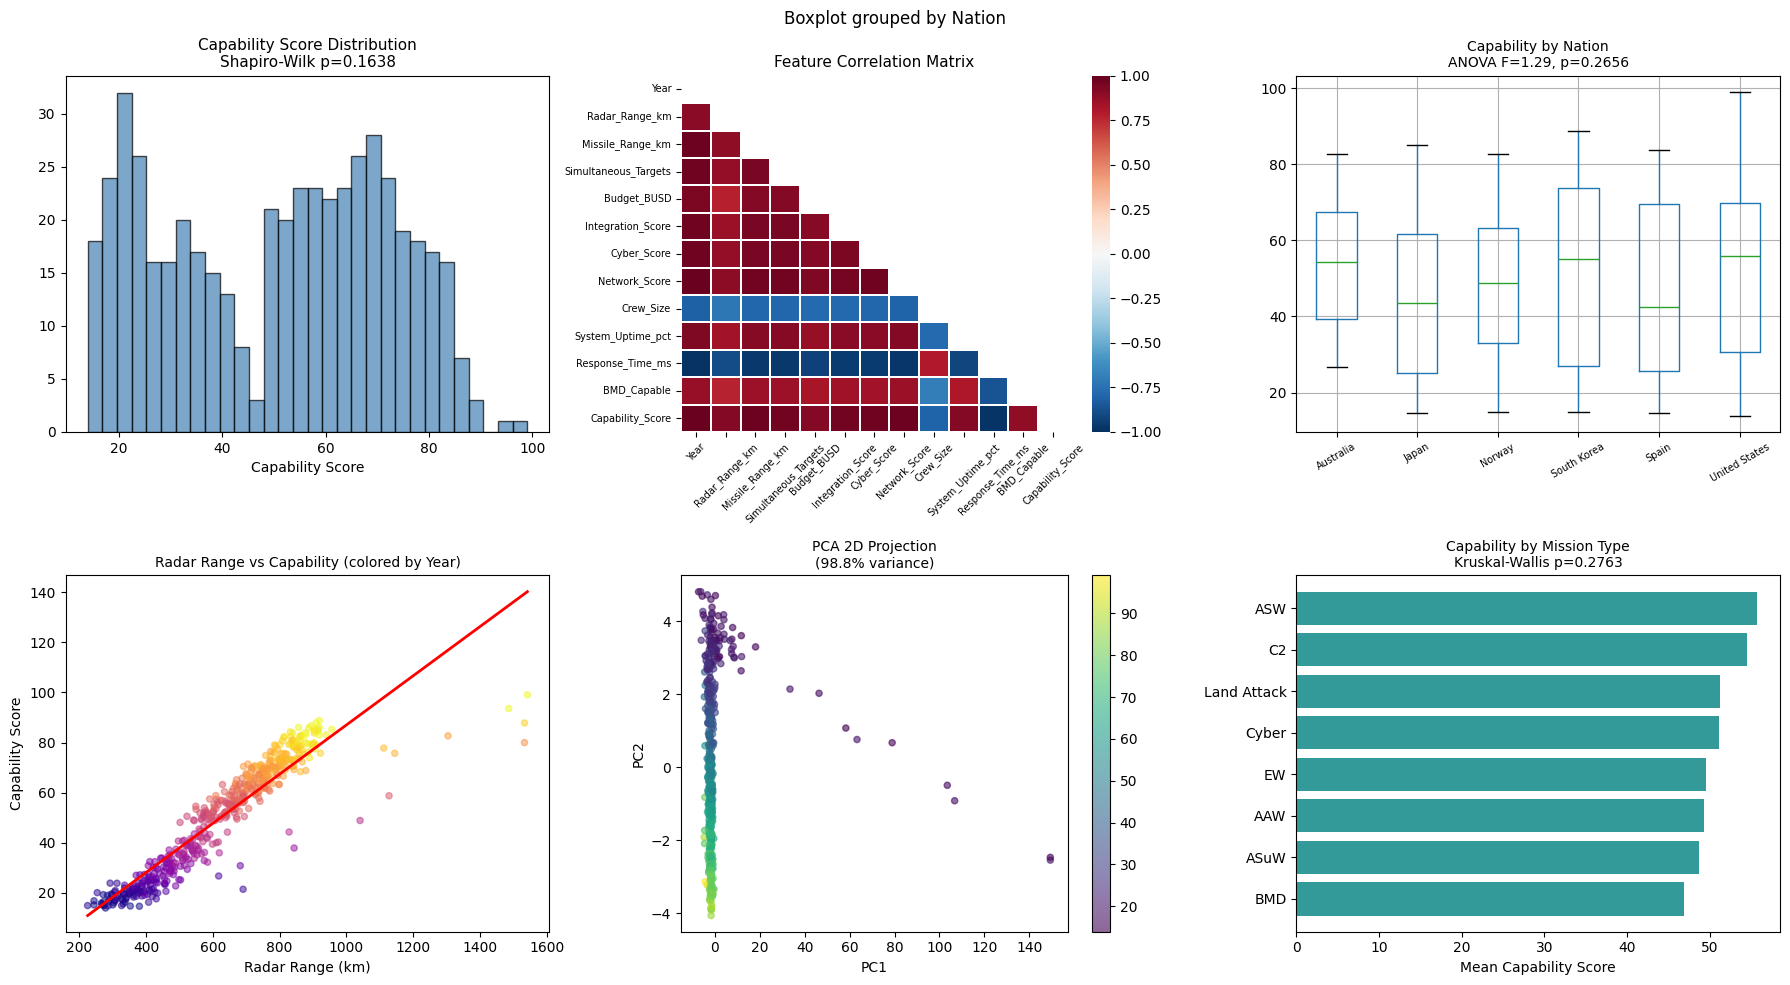

 EDA complete


In [5]:
# CELL 5: Advanced EDA with statistical tests

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Advanced EDA — Aegis Combat System Dataset', fontsize=16, fontweight='bold')

# 1. Target distribution + normality test
axes[0,0].hist(df['Capability_Score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
stat, p = stats.shapiro(df['Capability_Score'].sample(50))
axes[0,0].set_title(f'Capability Score Distribution\nShapiro-Wilk p={p:.4f}', fontsize=11)
axes[0,0].set_xlabel('Capability Score')

# 2. Correlation heatmap
corr = df[FEATURES[:12] + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0,1], annot=False, cmap='RdBu_r', mask=mask,
            center=0, vmin=-1, vmax=1, linewidths=0.3)
axes[0,1].set_title('Feature Correlation Matrix', fontsize=11)
axes[0,1].tick_params(axis='x', rotation=45, labelsize=7)
axes[0,1].tick_params(axis='y', rotation=0, labelsize=7)

# 3. Capability by Nation (ANOVA)
groups = [df[df['Nation']==n]['Capability_Score'].values for n in df['Nation'].unique()]
f_stat, p_anova = stats.f_oneway(*groups)
df.boxplot(column='Capability_Score', by='Nation', ax=axes[0,2], rot=30)
axes[0,2].set_title(f'Capability by Nation\nANOVA F={f_stat:.2f}, p={p_anova:.4f}', fontsize=10)
axes[0,2].set_xlabel(''); plt.sca(axes[0,2])
plt.xticks(fontsize=7)

# 4. Feature vs target scatter with regression line
axes[1,0].scatter(df['Radar_Range_km'], df['Capability_Score'],
                  c=df['Year'], cmap='plasma', alpha=0.5, s=20)
m, b = np.polyfit(df['Radar_Range_km'], df['Capability_Score'], 1)
x_l = np.linspace(df['Radar_Range_km'].min(), df['Radar_Range_km'].max(), 100)
axes[1,0].plot(x_l, m*x_l+b, 'r-', linewidth=2)
axes[1,0].set_title('Radar Range vs Capability (colored by Year)', fontsize=10)
axes[1,0].set_xlabel('Radar Range (km)'); axes[1,0].set_ylabel('Capability Score')

# 5. PCA 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.fit_transform(X))
scatter = axes[1,1].scatter(X_pca[:,0], X_pca[:,1],
                            c=y, cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, ax=axes[1,1])
axes[1,1].set_title(f'PCA 2D Projection\n({pca.explained_variance_ratio_.sum()*100:.1f}% variance)', fontsize=10)
axes[1,1].set_xlabel('PC1'); axes[1,1].set_ylabel('PC2')

# 6. Mission type vs capability (Kruskal-Wallis)
mission_groups = [df[df['Mission_Type']==m]['Capability_Score'].values
                  for m in df['Mission_Type'].unique()]
kw_stat, kw_p = stats.kruskal(*mission_groups)
means = df.groupby('Mission_Type')['Capability_Score'].mean().sort_values()
axes[1,2].barh(means.index, means.values, color='teal', alpha=0.8)
axes[1,2].set_title(f'Capability by Mission Type\nKruskal-Wallis p={kw_p:.4f}', fontsize=10)
axes[1,2].set_xlabel('Mean Capability Score')

plt.tight_layout()
plt.show()
print(" EDA complete")

In [6]:
# CELL 6: Benchmark 8 ML models with 5-fold cross-validation

models = {
    'Linear Regression':      LinearRegression(),
    'Ridge':                  Ridge(alpha=1.0),
    'Lasso':                  Lasso(alpha=0.01),
    'Random Forest':          RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost':                xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM':               lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    'SVR (RBF)':              SVR(kernel='rbf', C=10, epsilon=0.1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f"{'Model':<25} {'CV R²':>8} {'CV RMSE':>10} {'Test R²':>8} {'Test MAE':>10}")
print("-"*65)

for name, model in models.items():
    # Cross-validation on train set
    cv_r2   = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_train_sc, y_train,
                       cv=kf, scoring='neg_mean_squared_error'))

    # Fit and test
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    test_r2  = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model': name,
        'CV_R2_mean': cv_r2.mean(),
        'CV_R2_std': cv_r2.std(),
        'CV_RMSE_mean': cv_rmse.mean(),
        'Test_R2': test_r2,
        'Test_MAE': test_mae,
        'Predictions': y_pred
    })
    print(f"{name:<25} {cv_r2.mean():>8.4f} {cv_rmse.mean():>10.4f} "
          f"{test_r2:>8.4f} {test_mae:>10.4f}")

results_df = pd.DataFrame(results).sort_values('Test_R2', ascending=False)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best model: {best_model_name}")

Model                        CV R²    CV RMSE  Test R²   Test MAE
-----------------------------------------------------------------
Linear Regression           0.9897     2.2086   0.9901     1.6423
Ridge                       0.9900     2.1839   0.9902     1.6517
Lasso                       0.9901     2.1671   0.9903     1.6329
Random Forest               0.9837     2.7768   0.9844     1.8793
Gradient Boosting           0.9841     2.7494   0.9860     1.9635
XGBoost                     0.9812     2.9858   0.9829     2.0429
LightGBM                    0.9830     2.8500   0.9854     1.9896
SVR (RBF)                   0.9809     3.0067   0.9849     1.8623

 Best model: Lasso


In [7]:
# CELL 7: Bayesian Hyperparameter Optimization (Optuna) for XGBoost

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_train_sc, y_train, cv=3, scoring='r2')
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n Optuna complete!")
print(f"   Best R²: {study.best_value:.5f}")
print(f"   Best params: {study.best_params}")

# Retrain with best params
best_xgb = xgb.XGBRegressor(**study.best_params, random_state=42, verbosity=0)
best_xgb.fit(X_train_sc, y_train)
y_pred_best = best_xgb.predict(X_test_sc)
print(f"\n   Tuned XGBoost Test R²  : {r2_score(y_test, y_pred_best):.5f}")
print(f"   Tuned XGBoost Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"   Tuned XGBoost Test MAE : {mean_absolute_error(y_test, y_pred_best):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 Optuna complete!
   Best R²: 0.98664
   Best params: {'n_estimators': 304, 'max_depth': 3, 'learning_rate': 0.032163275260126106, 'subsample': 0.6387292437484665, 'colsample_bytree': 0.7441463307870537, 'reg_alpha': 0.06439252762740261, 'reg_lambda': 0.0019545258595089496}

   Tuned XGBoost Test R²  : 0.98654
   Tuned XGBoost Test RMSE: 2.3552
   Tuned XGBoost Test MAE : 1.8868


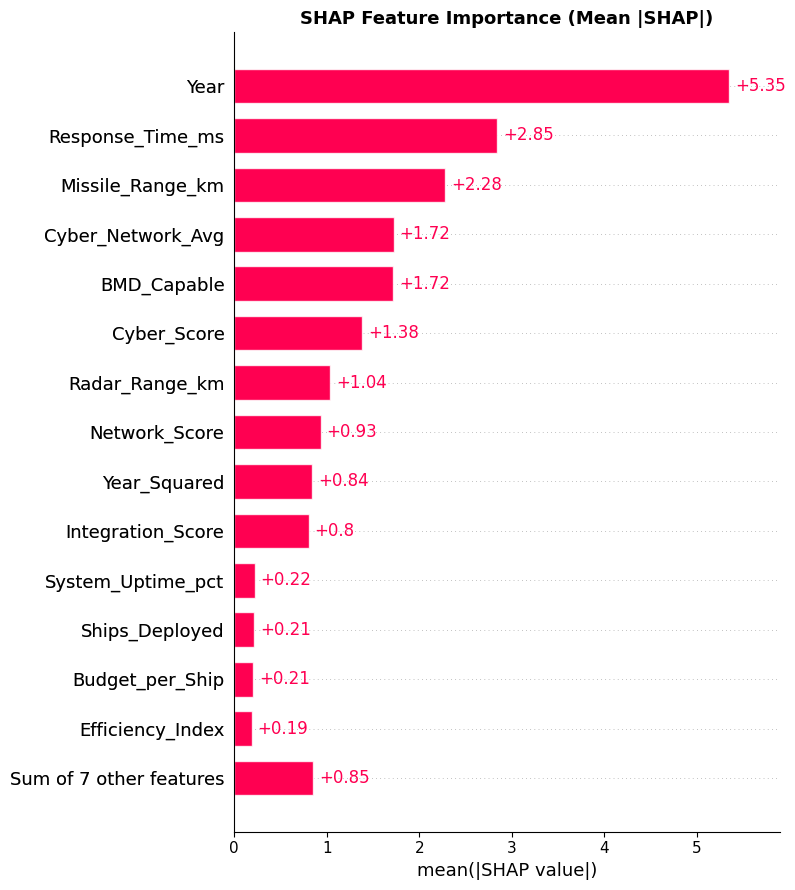

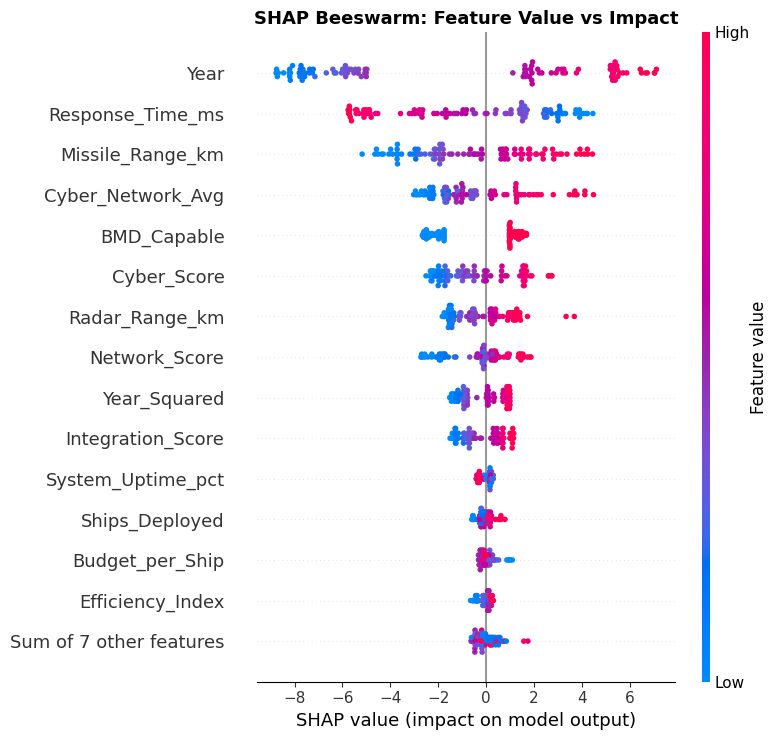

Top feature: Year (index 0)


<Figure size 1000x500 with 0 Axes>

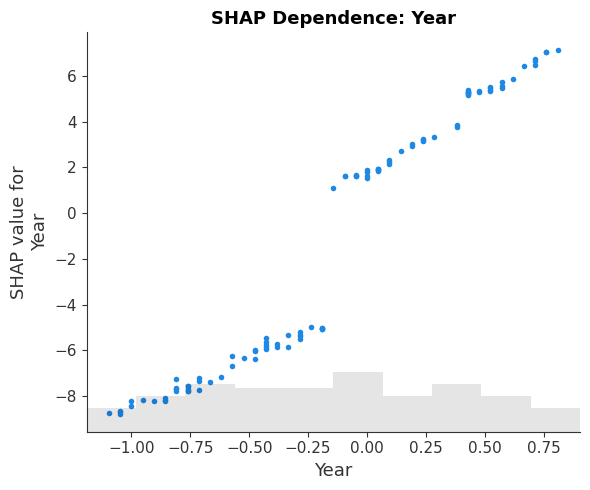

 SHAP analysis complete


In [10]:
# CELL 8: SHAP — Model Explainability (FIXED)

import shap
import matplotlib.pyplot as plt
import numpy as np

# Create explainer and compute SHAP values
explainer = shap.Explainer(best_xgb, X_train_sc)
shap_values = explainer(X_test_sc)

# Fix: attach feature names manually to the Explanation object
shap_values.feature_names = FEATURES

# --- Plot 1: SHAP Bar Summary ---
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False, max_display=15)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot 2: SHAP Beeswarm ---
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.title('SHAP Beeswarm: Feature Value vs Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot 3: Dependence plot (FIXED — use index-based slice correctly) ---
top_feature_idx = int(np.argmax(np.abs(shap_values.values).mean(0)))
top_feature_name = FEATURES[top_feature_idx]
print(f"Top feature: {top_feature_name} (index {top_feature_idx})")

# Extract single-feature Explanation object properly
shap_single = shap_values[:, top_feature_idx]

plt.figure(figsize=(10, 5))
shap.plots.scatter(shap_single, show=False)
plt.title(f'SHAP Dependence: {top_feature_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" SHAP analysis complete")

Epoch  25/150 | Train Loss: 4.8462 | Val Loss: 2.8361
Epoch  50/150 | Train Loss: 4.4295 | Val Loss: 1.8478
Epoch  75/150 | Train Loss: 4.4453 | Val Loss: 2.1953
Epoch 100/150 | Train Loss: 3.7254 | Val Loss: 2.1499
Epoch 125/150 | Train Loss: 4.0810 | Val Loss: 1.9596
Epoch 150/150 | Train Loss: 4.4416 | Val Loss: 2.8066

 Neural Network  R²  : 0.95729
   Neural Network  RMSE: 4.1955


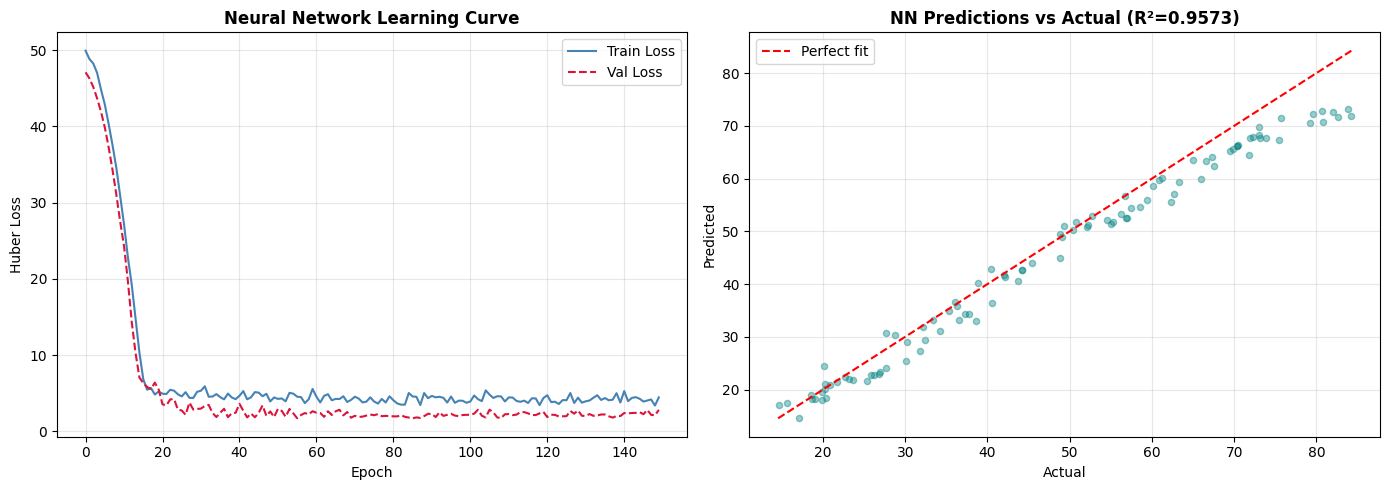

In [11]:
# CELL 9: Deep Neural Network (PyTorch) for Capability Score Regression

class AegisNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# Tensors
X_tr = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr = torch.tensor(y_train.values, dtype=torch.float32)
X_te = torch.tensor(X_test_sc, dtype=torch.float32)
y_te = torch.tensor(y_test.values, dtype=torch.float32)

train_ds = TensorDataset(X_tr, y_tr)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_nn = AegisNet(X_tr.shape[1]).to(device)
criterion = nn.HuberLoss()   # robust to outliers
optimizer = optim.AdamW(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

train_losses, val_losses = [], []
EPOCHS = 150

for epoch in range(EPOCHS):
    model_nn.train()
    epoch_loss = 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_nn(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_nn.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    model_nn.eval()
    with torch.no_grad():
        val_pred = model_nn(X_te.to(device))
        val_loss = criterion(val_pred, y_te.to(device)).item()

    train_losses.append(epoch_loss / len(train_dl))
    val_losses.append(val_loss)

    if (epoch+1) % 25 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

model_nn.eval()
with torch.no_grad():
    nn_preds = model_nn(X_te.to(device)).cpu().numpy()

nn_r2   = r2_score(y_test, nn_preds)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_preds))
print(f"\n Neural Network  R²  : {nn_r2:.5f}")
print(f"   Neural Network  RMSE: {nn_rmse:.4f}")

# Plot learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses, label='Val Loss', color='crimson', linestyle='--')
axes[0].set_title('Neural Network Learning Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, nn_preds, alpha=0.4, color='teal', s=20)
lims = [min(y_test.min(), nn_preds.min()), max(y_test.max(), nn_preds.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title(f'NN Predictions vs Actual (R²={nn_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


ADF Statistic : -3.0754
p-value       : 0.0284
Series is stationary ✅


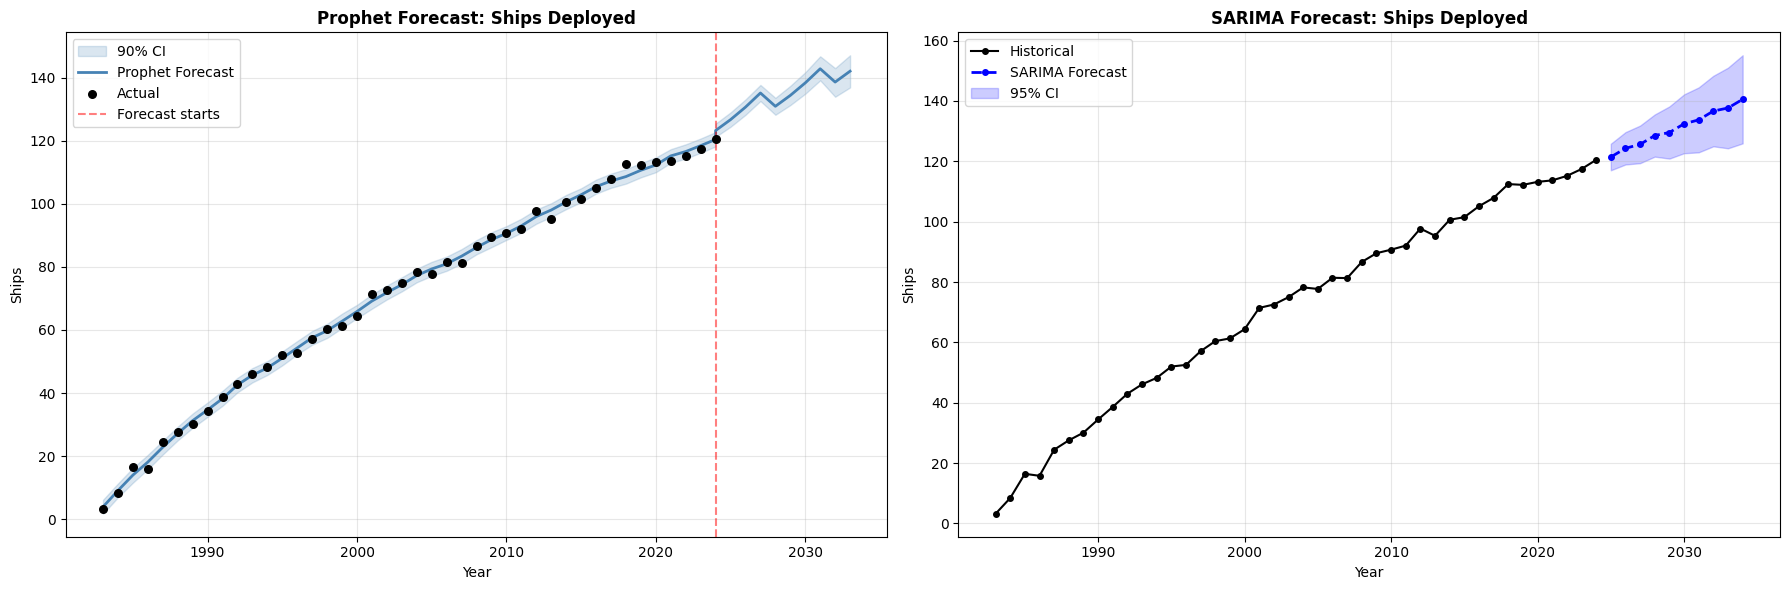

 Forecasting complete


In [13]:
# CELL 10: Time Series — Prophet + SARIMA (FIXED)

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Prepare annual aggregated time series
ts_df = df.groupby('Year').agg(
    Ships=('Ships_Deployed','mean'),
    Budget=('Budget_BUSD','mean'),
    Capability=('Capability_Score','mean')
).reset_index().sort_values('Year')

# FIX 1: Ensure Year is integer
ts_df['Year'] = ts_df['Year'].astype(int)

# --- PROPHET ---
prophet_df = ts_df[['Year','Ships']].rename(columns={'Year':'ds','Ships':'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')
prophet_df['budget'] = ts_df['Budget'].values

m = Prophet(
    changepoint_prior_scale=0.3,
    seasonality_mode='additive',
    interval_width=0.90
)
m.add_regressor('budget')
m.fit(prophet_df)

future = m.make_future_dataframe(periods=10, freq='YE')
future['budget'] = np.append(
    ts_df['Budget'].values,
    np.linspace(ts_df['Budget'].iloc[-1],
                ts_df['Budget'].iloc[-1] + 0.8, 10)
)
forecast = m.predict(future)

# --- SARIMA (FIX 2: simpler order to avoid convergence failure) ---
sarima_model = SARIMAX(
    ts_df['Ships'],
    order=(1, 1, 1),              # simplified from (2,1,2)
    seasonal_order=(0, 1, 1, 4),  # simplified seasonal
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False, maxiter=200)
sarima_forecast = sarima_result.get_forecast(steps=10)
sarima_mean = sarima_forecast.predicted_mean
sarima_ci   = sarima_forecast.conf_int()

# ADF Stationarity Test
adf_result = adfuller(ts_df['Ships'].dropna())
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print("Series is", "stationary ✅" if adf_result[1] < 0.05 else "non-stationary ⚠️")

# FIX 3: Cast future years to int explicitly
max_year     = int(ts_df['Year'].max())
future_years = list(range(max_year + 1, max_year + 11))  # guaranteed int range

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Prophet plot
axes[0].fill_between(
    forecast['ds'].dt.year,
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.2, color='steelblue', label='90% CI'
)
axes[0].plot(forecast['ds'].dt.year, forecast['yhat'],
             color='steelblue', linewidth=2, label='Prophet Forecast')
axes[0].scatter(ts_df['Year'], ts_df['Ships'],
                color='black', zorder=5, s=30, label='Actual')
axes[0].axvline(max_year, color='red', linestyle='--', alpha=0.5, label='Forecast starts')
axes[0].set_title('Prophet Forecast: Ships Deployed', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Ships')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# SARIMA plot
axes[1].plot(ts_df['Year'], ts_df['Ships'],
             'ko-', markersize=4, label='Historical', linewidth=1.5)
axes[1].plot(future_years, sarima_mean.values,
             'b--o', markersize=4, label='SARIMA Forecast', linewidth=2)
axes[1].fill_between(
    future_years,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    alpha=0.2, color='blue', label='95% CI'
)
axes[1].set_title('SARIMA Forecast: Ships Deployed', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Ships')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(" Forecasting complete")

Isolation Forest anomalies: 25
DBSCAN anomalies           : 10
Both agree (outliers)      : 10


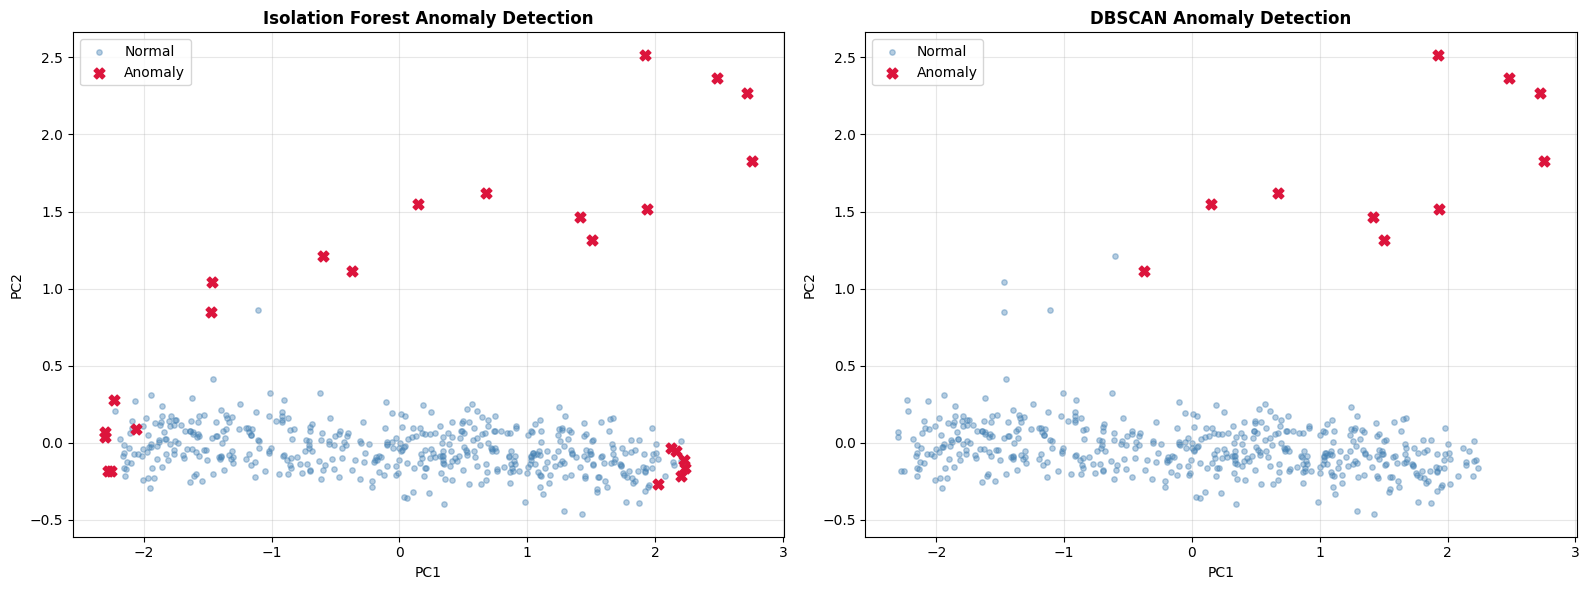


Anomaly Profile vs Normal:
             Radar_Range_km  Budget_BUSD  Response_Time_ms  Cyber_Score  \
Anomaly_ISO                                                               
0                    614.64         2.42           2658.59        42.71   
1                    878.15         1.82           2521.68        51.57   

             Capability_Score  
Anomaly_ISO                    
0                       50.06  
1                       57.65  


In [14]:
# CELL 11: Anomaly Detection — Isolation Forest + DBSCAN

anomaly_features = ['Radar_Range_km','Budget_BUSD','Response_Time_ms',
                    'Cyber_Score','Capability_Score']
X_anom = scaler.fit_transform(df[anomaly_features].fillna(df[anomaly_features].median()))

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
iso_labels = iso.fit_predict(X_anom)
iso_scores = iso.score_samples(X_anom)
df['Anomaly_ISO'] = (iso_labels == -1).astype(int)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_anom)
df['Anomaly_DBSCAN'] = (dbscan_labels == -1).astype(int)

print(f"Isolation Forest anomalies: {df['Anomaly_ISO'].sum()}")
print(f"DBSCAN anomalies           : {df['Anomaly_DBSCAN'].sum()}")
print(f"Both agree (outliers)      : {((df['Anomaly_ISO']==1) & (df['Anomaly_DBSCAN']==1)).sum()}")

# PCA for visualization
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_anom)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, title in zip(
    axes,
    [iso_labels, dbscan_labels],
    ['Isolation Forest Anomaly Detection', 'DBSCAN Anomaly Detection']
):
    normal = labels != -1
    ax.scatter(X_2d[normal, 0], X_2d[normal, 1],
               c='steelblue', s=15, alpha=0.4, label='Normal')
    ax.scatter(X_2d[~normal, 0], X_2d[~normal, 1],
               c='crimson', s=60, marker='X', zorder=5, label='Anomaly')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Anomaly profile report
print("\nAnomaly Profile vs Normal:")
print(df.groupby('Anomaly_ISO')[anomaly_features].mean().round(2))

Optimal k by Silhouette: 2


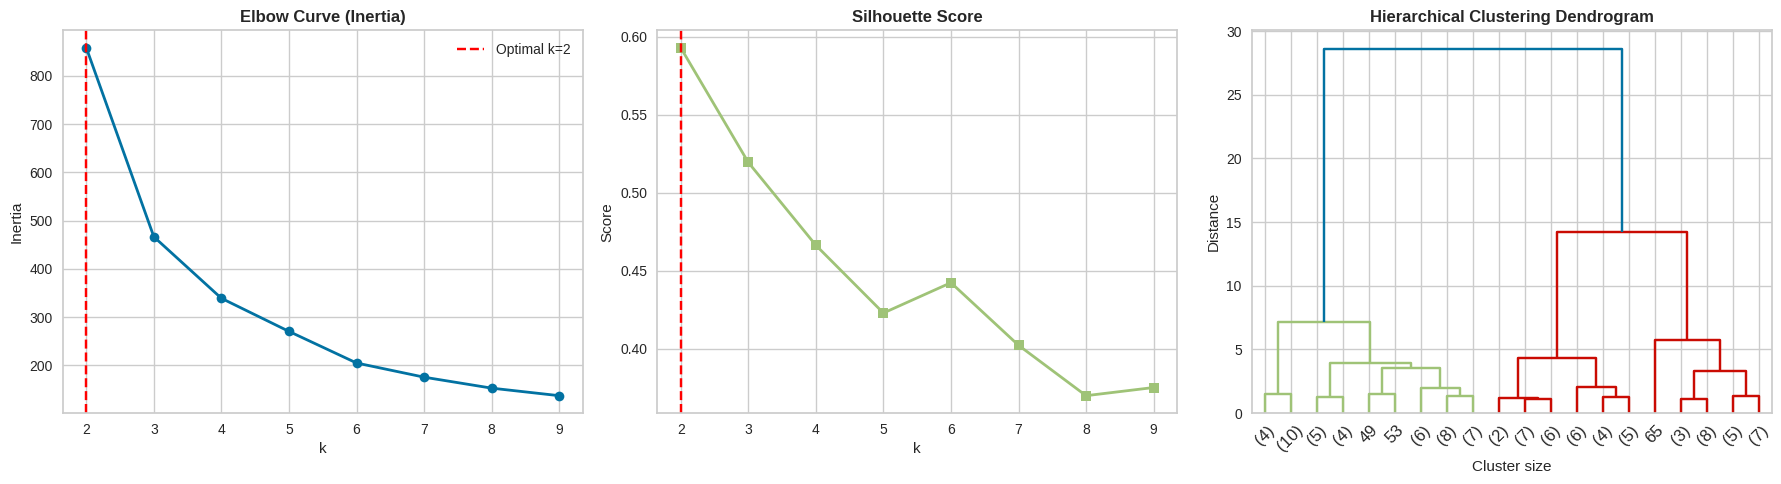


Cluster Profiles:
            Year  Radar_Range_km  Budget_BUSD  Cyber_Score  Network_Score  \
Cluster                                                                     
0        2013.52          766.50         3.22        63.55          71.21   
1        1992.24          445.47         1.30        16.32          23.62   

         Capability_Score  
Cluster                    
0                   67.15  
1                   28.46  


In [15]:
# CELL 12: Optimal Clustering with Elbow, Silhouette, Davies-Bouldin + Dendrogram

from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer

cluster_features_adv = ['Year','Radar_Range_km','Budget_BUSD',
                        'Cyber_Score','Network_Score','Capability_Score']
X_cl = StandardScaler().fit_transform(df[cluster_features_adv])

# Elbow + Silhouette scores
k_range = range(2, 10)
inertia, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl, labels))
    db_scores.append(davies_bouldin_score(X_cl, labels))

optimal_k = k_range.start + np.argmax(sil_scores)
print(f"Optimal k by Silhouette: {optimal_k}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertia, 'bo-', linewidth=2)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[0].set_title('Elbow Curve (Inertia)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(list(k_range), sil_scores, 'gs-', linewidth=2)
axes[1].axvline(optimal_k, color='red', linestyle='--')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

# Dendrogram
Z = linkage(X_cl[:100], method='ward')
dendrogram(Z, ax=axes[2], truncate_mode='lastp', p=20,
           leaf_rotation=45, color_threshold=0.7*max(Z[:,2]))
axes[2].set_title('Hierarchical Clustering Dendrogram', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster size'); axes[2].set_ylabel('Distance')

plt.tight_layout()
plt.show()

# Final clustering
final_km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = final_km.fit_predict(X_cl)

print("\nCluster Profiles:")
print(df.groupby('Cluster')[cluster_features_adv].mean().round(2))

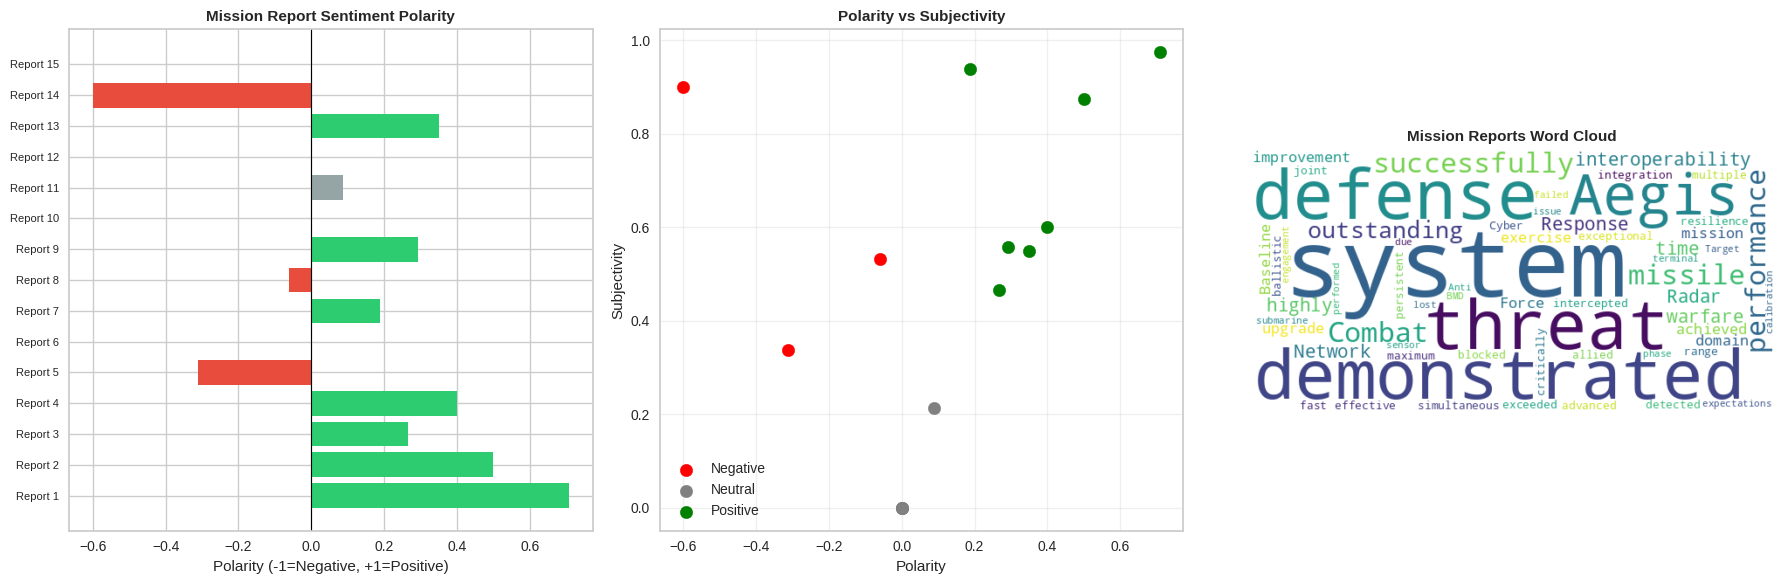


Sentiment Summary:
         polarity                                                   \
            count   mean    std    min    25%    50%    75%    max   
label                                                                
Negative      3.0 -0.324  0.270 -0.600 -0.456 -0.312 -0.186 -0.060   
Neutral       5.0  0.017  0.039  0.000  0.000  0.000  0.000  0.087   
Positive      7.0  0.386  0.173  0.188  0.279  0.350  0.450  0.708   

         subjectivity                                                   
                count   mean    std    min    25%    50%    75%    max  
label                                                                   
Negative          3.0  0.590  0.285  0.338  0.436  0.533  0.716  0.900  
Neutral           5.0  0.043  0.095  0.000  0.000  0.000  0.000  0.213  
Positive          7.0  0.709  0.212  0.467  0.554  0.600  0.906  0.975  


In [16]:
# CELL 13: NLP Analysis — Synthetic Mission Report Texts

mission_reports = [
    "Aegis successfully intercepted ballistic missile at maximum range. System performance was exceptional.",
    "Combat system integration with allied forces demonstrated outstanding interoperability in joint exercises.",
    "Radar detected multiple simultaneous threats. Response time was critically fast and highly effective.",
    "Cyber defense systems blocked advanced persistent threat. Network resilience exceeded expectations.",
    "BMD engagement failed due to sensor calibration issue. Target was lost during terminal phase.",
    "Anti-submarine warfare systems performed below standard. Sonar resolution needs urgent improvement.",
    "All mission objectives achieved. Crew performance was outstanding under extreme combat pressure.",
    "System suffered critical failure during live fire exercise. Emergency protocols were activated.",
    "Baseline 9 upgrade successfully demonstrated enhanced missile defense capability over previous version.",
    "Electronic warfare suite neutralized enemy radar. Stealth approach was executed with precision.",
    "Interoperability with Japanese Maritime Self-Defense Force was seamless and highly commendable.",
    "Response time to emerging threats was slower than acceptable parameters. Recalibration required.",
    "Full spectrum dominance achieved across all mission domains. System readiness is at peak level.",
    "Communication system latency introduced dangerous delays. Network infrastructure requires upgrade.",
    "Aegis Baseline 10 demonstrated transformative improvements in multi-domain battlespace awareness.",
]

# Sentiment analysis
sentiments = []
for text in mission_reports:
    blob = TextBlob(text)
    sentiments.append({
        'text': text[:60] + '...',
        'polarity': round(blob.sentiment.polarity, 3),
        'subjectivity': round(blob.sentiment.subjectivity, 3),
        'label': 'Positive' if blob.sentiment.polarity > 0.1
                 else 'Negative' if blob.sentiment.polarity < -0.05
                 else 'Neutral'
    })

sent_df = pd.DataFrame(sentiments)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Polarity distribution
colors = ['#2ecc71' if l=='Positive' else '#e74c3c' if l=='Negative' else '#95a5a6'
          for l in sent_df['label']]
axes[0].barh(range(len(sent_df)), sent_df['polarity'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Mission Report Sentiment Polarity', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Polarity (-1=Negative, +1=Positive)')
axes[0].set_yticks(range(len(sent_df)))
axes[0].set_yticklabels([f"Report {i+1}" for i in range(len(sent_df))], fontsize=8)

# 2. Polarity vs Subjectivity scatter
c_map = {'Positive':'green','Negative':'red','Neutral':'gray'}
for label, group in sent_df.groupby('label'):
    axes[1].scatter(group['polarity'], group['subjectivity'],
                    label=label, color=c_map[label], s=80, zorder=5)
axes[1].set_title('Polarity vs Subjectivity', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Polarity'); axes[1].set_ylabel('Subjectivity')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3. WordCloud
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
all_text = ' '.join(mission_reports)
wc = WordCloud(width=600, height=300, background_color='white',
               colormap='viridis', stopwords=stop_words,
               max_words=60).generate(all_text)
axes[2].imshow(wc, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('Mission Reports Word Cloud', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSentiment Summary:")
print(sent_df[['label','polarity','subjectivity']].groupby('label').describe().round(3))

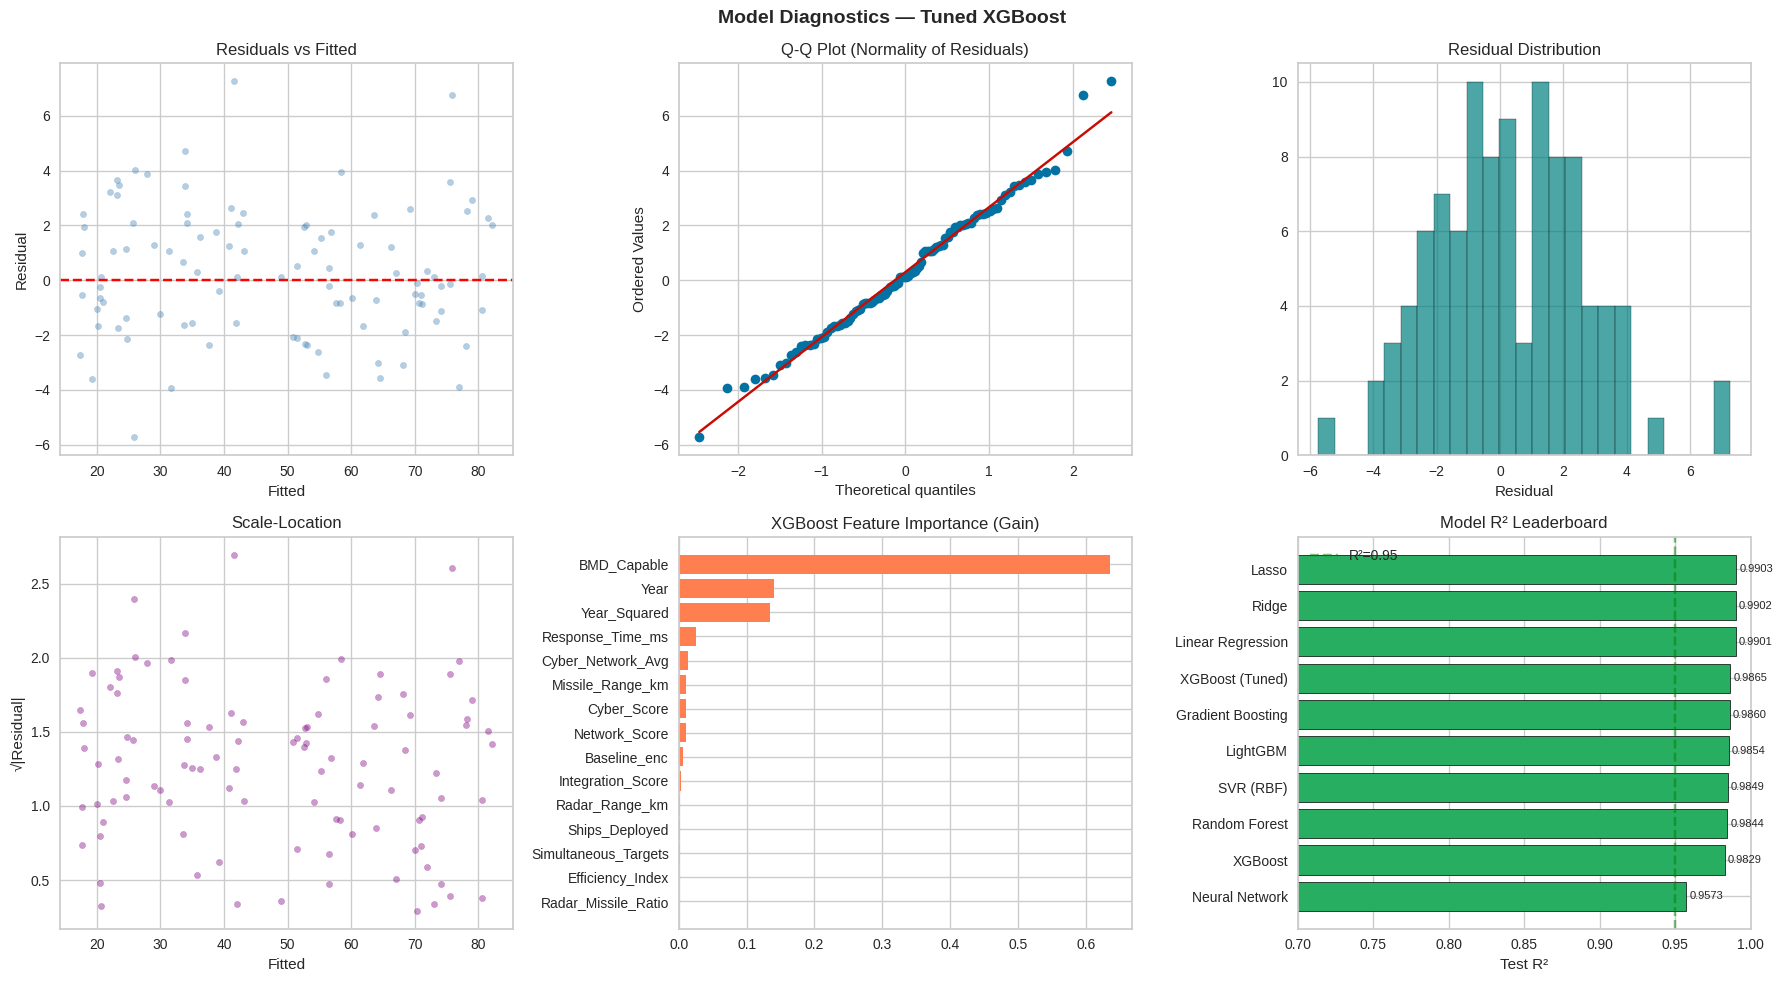

In [17]:
# CELL 14: Comprehensive residual analysis + final model leaderboard

best_preds = y_pred_best  # Tuned XGBoost
residuals = y_test.values - best_preds

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Diagnostics — Tuned XGBoost', fontsize=14, fontweight='bold')

# 1. Residuals vs fitted
axes[0,0].scatter(best_preds, residuals, alpha=0.4, color='steelblue', s=20)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals vs Fitted'); axes[0,0].set_xlabel('Fitted'); axes[0,0].set_ylabel('Residual')

# 2. Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot (Normality of Residuals)')

# 3. Residual histogram
axes[0,2].hist(residuals, bins=25, color='teal', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Residual Distribution'); axes[0,2].set_xlabel('Residual')

# 4. Scale-location
axes[1,0].scatter(best_preds, np.sqrt(np.abs(residuals)), alpha=0.4, color='purple', s=20)
axes[1,0].set_title('Scale-Location'); axes[1,0].set_xlabel('Fitted')
axes[1,0].set_ylabel('√|Residual|')

# 5. Feature importance (XGBoost native)
feat_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)[:15]
axes[1,1].barh(feat_imp.index[::-1], feat_imp.values[::-1], color='coral')
axes[1,1].set_title('XGBoost Feature Importance (Gain)')

# 6. Model leaderboard
models_compare = {**{r['Model']: r['Test_R2'] for r in results},
                  'XGBoost (Tuned)': r2_score(y_test, best_preds),
                  'Neural Network': nn_r2}
sorted_models = dict(sorted(models_compare.items(), key=lambda x: x[1]))
colors_bar = ['#e74c3c' if v < 0.90 else '#f39c12' if v < 0.95 else '#27ae60'
              for v in sorted_models.values()]
axes[1,2].barh(list(sorted_models.keys()), list(sorted_models.values()),
               color=colors_bar, edgecolor='black', linewidth=0.5)
axes[1,2].axvline(0.95, color='green', linestyle='--', alpha=0.5, label='R²=0.95')
axes[1,2].set_title('Model R² Leaderboard'); axes[1,2].set_xlabel('Test R²')
axes[1,2].set_xlim(0.7, 1.0); axes[1,2].legend()
for i, (k, v) in enumerate(sorted_models.items()):
    axes[1,2].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# CELL 15: Advanced Interactive Plotly Dashboard (FIXED)

from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA for cluster/anomaly plots
pca_out = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(df[FEATURES].fillna(0))
)

# Sorted models for leaderboard
leaderboard = {**{r['Model']: r['Test_R2'] for r in results},
               'XGBoost (Tuned)': r2_score(y_test, best_preds),
               'Neural Network':  nn_r2}
sorted_models = dict(sorted(leaderboard.items(), key=lambda x: x[1]))

# FIX: Separate 3D subplot — build it independently
fig_3d = go.Figure(go.Scatter3d(
    x=df['Budget_BUSD'],
    y=df['Cyber_Score'],
    z=df['Capability_Score'],
    mode='markers',
    marker=dict(
        size=3,
        color=df['Year'],
        colorscale='Viridis',
        opacity=0.7,
        colorbar=dict(title='Year', thickness=10)
    ),
    name='Budget/Cyber/Capability'
))
fig_3d.update_layout(
    title='Budget vs Cyber Score vs Capability (3D)',
    scene=dict(
        xaxis_title='Budget (B USD)',
        yaxis_title='Cyber Score',
        zaxis_title='Capability Score'
    ),
    height=500,
    margin=dict(l=0, r=0, t=40, b=0)
)
fig_3d.show()

# FIX: 2D-only subplots (no 3D spec — avoids xaxis conflict)
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        'Ship Deployment (Historical)',
        'Model R² Leaderboard',
        'Capability by Nation',
        'PCA — Clusters',
        'PCA — Anomalies',
        'Cyber Score Over Time',
        'Radar Range Over Time',
        'Residuals vs Fitted',
        'Silhouette Score vs k'
    ]
)

# --- ROW 1 ---
# R1C1: Historical ships
fig.add_trace(go.Scatter(
    x=ts_df['Year'], y=ts_df['Ships'],
    mode='lines+markers', name='Ships',
    line=dict(color='navy', width=2)
), row=1, col=1)

# R1C2: Model leaderboard
fig.add_trace(go.Bar(
    x=list(sorted_models.values()),
    y=list(sorted_models.keys()),
    orientation='h',
    marker=dict(color='teal'),
    name='R²'
), row=1, col=2)

# R1C3: Box plots by nation
for nation in df['Nation'].unique():
    fig.add_trace(go.Box(
        y=df[df['Nation'] == nation]['Capability_Score'],
        name=nation, showlegend=False
    ), row=1, col=3)

# --- ROW 2 ---
# R2C1: PCA clusters
colors_cluster = ['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261','#264653']
for i, c in enumerate(sorted(df['Cluster'].unique())):
    mask = df['Cluster'] == c
    fig.add_trace(go.Scatter(
        x=pca_out[mask, 0], y=pca_out[mask, 1],
        mode='markers',
        marker=dict(size=5, opacity=0.6,
                    color=colors_cluster[i % len(colors_cluster)]),
        name=f'Cluster {c}'
    ), row=2, col=1)

# R2C2: Anomalies
normal_mask = df['Anomaly_ISO'] == 0
anom_mask   = df['Anomaly_ISO'] == 1
fig.add_trace(go.Scatter(
    x=pca_out[normal_mask, 0], y=pca_out[normal_mask, 1],
    mode='markers',
    marker=dict(size=4, color='steelblue', opacity=0.4),
    name='Normal'
), row=2, col=2)
fig.add_trace(go.Scatter(
    x=pca_out[anom_mask, 0], y=pca_out[anom_mask, 1],
    mode='markers',
    marker=dict(size=9, color='crimson', symbol='x'),
    name='Anomaly'
), row=2, col=2)

# R2C3: Cyber score trend
yearly_cyber = df.groupby('Year')['Cyber_Score'].mean()
fig.add_trace(go.Scatter(
    x=yearly_cyber.index, y=yearly_cyber.values,
    fill='tozeroy', name='Cyber Score',
    line=dict(color='orange', width=2)
), row=2, col=3)

# --- ROW 3 ---
# R3C1: Radar range trend
yearly_radar = df.groupby('Year')['Radar_Range_km'].mean()
fig.add_trace(go.Scatter(
    x=yearly_radar.index, y=yearly_radar.values,
    fill='tozeroy', name='Radar Range',
    line=dict(color='steelblue', width=2)
), row=3, col=1)

# R3C2: Residuals vs fitted (FIX: NO add_hline on subplots — use Scatter instead)
residuals = y_test.values - best_preds
fig.add_trace(go.Scatter(
    x=best_preds, y=residuals,
    mode='markers',
    marker=dict(size=4, opacity=0.5, color='purple'),
    name='Residuals'
), row=3, col=2)
# FIX: Draw zero line as a Scatter trace instead of add_hline
fig.add_trace(go.Scatter(
    x=[best_preds.min(), best_preds.max()],
    y=[0, 0],
    mode='lines',
    line=dict(color='red', dash='dash', width=1.5),
    name='Zero line',
    showlegend=False
), row=3, col=2)

# R3C3: Silhouette scores
fig.add_trace(go.Bar(
    x=list(k_range),
    y=sil_scores,
    marker=dict(color='green', opacity=0.8),
    name='Silhouette'
), row=3, col=3)

fig.update_layout(
    height=1000,
    title_text='<b>Aegis Combat System — Advanced Analytics Dashboard</b>',
    title_font_size=15,
    showlegend=False,
    template='plotly_white'
)

fig.show()
print(" Dashboard complete")

 Dashboard complete
